### Cargar dataset y construir matriz

Elegi el dataset Olivetti Faces.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

In [2]:
faces = fetch_olivetti_faces()
X = faces.data
y = faces.target

print(f"n x d: {X.shape}  |  Personas: {len(np.unique(y))}")
print(f"Rango de valores: [{X.min():.2f}, {X.max():.2f}]")

n x d: (400, 4096)  |  Personas: 40
Rango de valores: [0.00, 1.00]


In [3]:
# Centrar datos
x_mean = np.mean(X, axis=0)
X_c = X - x_mean

# Hacemos SVD
U, s, Vt = np.linalg.svd(X_c, full_matrices=False)


### Valores singulares y varianza explicada.

In [4]:
var_explicada = (s ** 2) / np.sum(s ** 2)
var_acumulada = np.cumsum(var_explicada)

k90 = np.searchsorted(var_acumulada, 0.90) + 1
k99 = np.searchsorted(var_acumulada, 0.99) + 1
print(f"Componentes para 90% de varianza: {k90}  |  para 99%: {k99} ")

Componentes para 90% de varianza: 66  |  para 99%: 260 


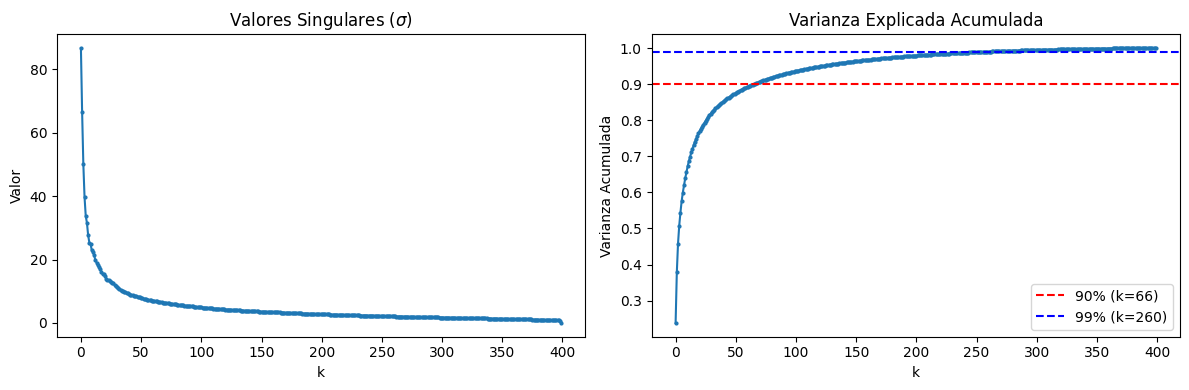

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s, marker='o', markersize=2, linestyle='-')
axes[0].set_title("Valores Singulares ($ \\sigma $)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Valor")

axes[1].plot(var_acumulada, marker='o', markersize=2, linestyle='-')
axes[1].axhline(0.90, color='r', linestyle='--', label=f'90% (k={k90})')
axes[1].axhline(0.99, color='b', linestyle='--', label=f'99% (k={k99})')
axes[1].set_title("Varianza Explicada Acumulada")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Varianza Acumulada")
axes[1].legend()
plt.tight_layout()
plt.show()

### Eigen-imagenes

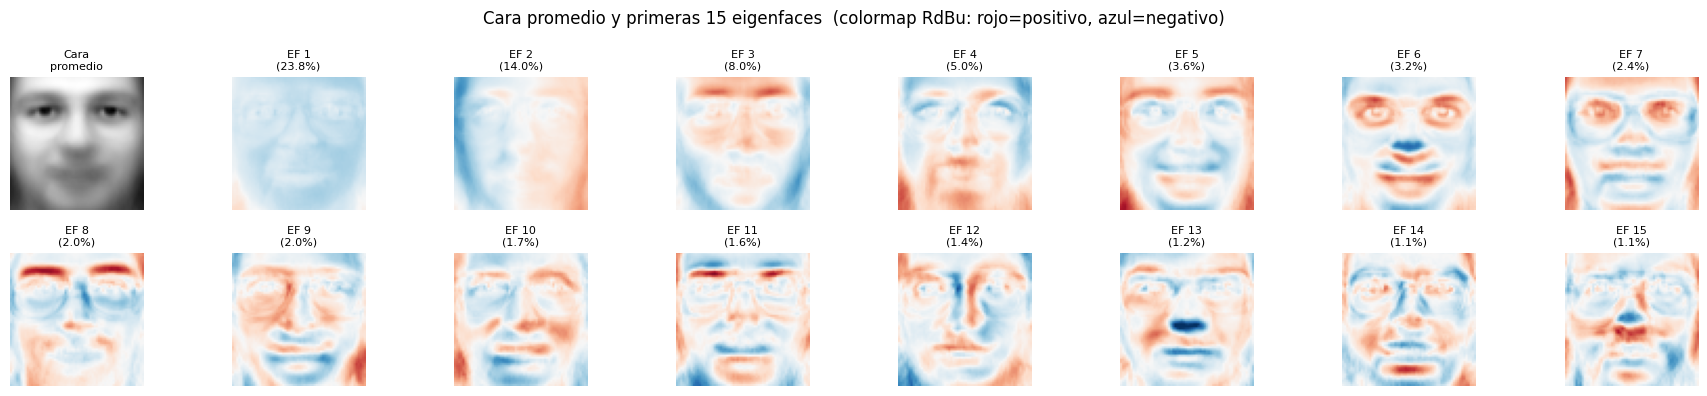

In [6]:
n_eigen = 15
fig, axes = plt.subplots(2, 8, figsize=(18, 4))

# Cara prom en la primera pos
axes[0, 0].imshow(x_mean.reshape(64, 64), cmap='gray')
axes[0, 0].set_title("Cara\npromedio", fontsize=8)
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flat[1:n_eigen + 1]):
    eigenface = Vt[i].reshape(64, 64)
    ax.imshow(eigenface, cmap='RdBu_r', vmin=-0.07, vmax=0.07)
    ax.set_title(f"EF {i+1}\n({var_explicada[i]:.1%})", fontsize=8)
    ax.axis('off')

for ax in axes.flat[n_eigen + 1:]:
    ax.axis('off')

fig.suptitle("Cara promedio y primeras 15 eigenfaces  (colormap RdBu: rojo=positivo, azul=negativo)")
plt.tight_layout()
plt.show()


### Reconstruccion progresiva

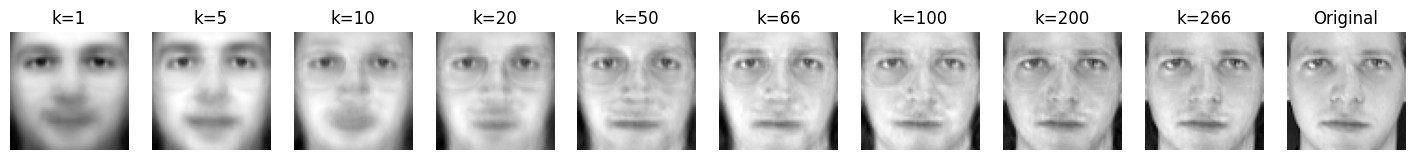

In [7]:
idx_img = 0 # Primera imagen
x_og = X[idx_img]
x_c = X_c[idx_img]

k_valores = [1, 5, 10, 20, 50, 66, 100, 200, 266]
fig, axes = plt.subplots(1, len(k_valores) + 1, figsize=(18, 3))

for i, k in enumerate(k_valores):
    # Proyectar y reconstruir
    z = x_c @ Vt[:k].T
    x_rec = x_mean + z @ Vt[:k]
    
    axes[i].imshow(x_rec.reshape(64, 64), cmap='gray')
    axes[i].set_title(f"k={k}")
    axes[i].axis('off')


axes[-1].imshow(x_og.reshape(64, 64), cmap='gray')
axes[-1].set_title("Original")
axes[-1].axis('off')
plt.show()